In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [3]:
# LOAD DATASET

df = pd.read_csv("heart.csv")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [4]:
# DATA EXPLORATION

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nTarget Variable Distribution:")
print(df['target'].value_counts())


Dataset Shape:
(1025, 14)

Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   

In [5]:
# DATA PREPROCESSING

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (820, 13)
Testing Data Shape: (205, 13)


In [6]:
# LOGISTIC REGRESSION MODEL

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n===== Logistic Regression Results =====")
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, lr_pred) * 100))
print("Precision: {:.2f}%".format(precision_score(y_test, lr_pred) * 100))
print("Recall: {:.2f}%".format(recall_score(y_test, lr_pred) * 100))
print("F1 Score: {:.2f}%".format(f1_score(y_test, lr_pred) * 100))



===== Logistic Regression Results =====
Accuracy: 79.51%
Precision: 75.63%
Recall: 87.38%
F1 Score: 81.08%


In [7]:
# RANDOM FOREST MODEL

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n===== Random Forest Results =====")
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, rf_pred) * 100))
print("Precision: {:.2f}%".format(precision_score(y_test, rf_pred) * 100))
print("Recall: {:.2f}%".format(recall_score(y_test, rf_pred) * 100))
print("F1 Score: {:.2f}%".format(f1_score(y_test, rf_pred) * 100))



===== Random Forest Results =====
Accuracy: 98.54%
Precision: 100.00%
Recall: 97.09%
F1 Score: 98.52%


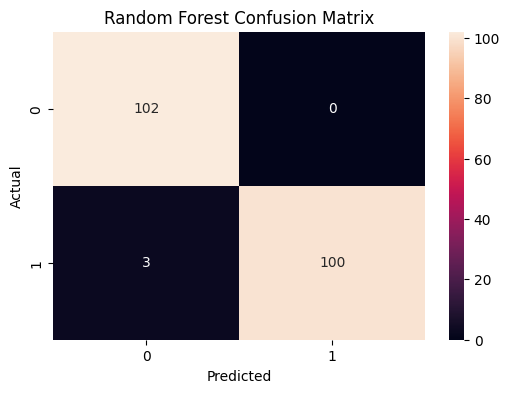

In [8]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [9]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)


Feature Importance:
     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


In [12]:
# MODEL COMPARISON

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})
print("\nModel Comparison:")
print(comparison)



Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.795122   0.756303  0.873786  0.810811
1        Random Forest  0.985366   1.000000  0.970874  0.985222


In [13]:
# FINAL CONCLUSION

best_model = comparison.loc[
    comparison['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = comparison['Accuracy'].max() * 100

print("\n===== Conclusion =====")
print(f"The best performing model is {best_model}.")
print(f"It achieved an accuracy of {best_accuracy:.2f}%.")
print("This model can be used for heart disease prediction based on patient medical data.")


===== Conclusion =====
The best performing model is Random Forest.
It achieved an accuracy of 98.54%.
This model can be used for heart disease prediction based on patient medical data.
